# Seminar 1 - A Song of Graphs and Search

---

**Course**: Graphs and Network Analysis

**Degree**: Artificial Intelligence Degree (UAB)

**Topic**: Practical seminar that includes exercises from units 1 to 6

**Activity description**: Most of us are familiar with the Game of Thrones books or series. For those who do not know it, it is a fictional series from the HBO chain, inspired by the series of novels "A Song of Ice and Fire", which tells the experiences of a group of characters from different noble houses on the fictional continent of *Westeros* to have control of the Iron Throne and rule the seven kingdoms that make up the territory. The series' success has spawned many blogs and other sources about the series, with additional resources. The graphs that we propose to use in this exercise represent the characters of the series (or books) as nodes, and their co-appearance in a scene (the weights of the edges are higher if two characters appear simultaneously more times). So we have a social network of characters. We will use these graphs to work on some of the concepts seen in the first units of the course (graph and node metrics, search and routes). Finally, we will generate synthetic graphs that simulate a realistic network.

## Qualification

**Submission**: An '.ipynb' file from the colab corresponding to each group will be delivered (this very same file, adding the code blocks and explanations that correspond to each activity). To get the file you will need to go to File --> Download. Remember that you will have to answer and analyze the different problems. Coding alone will NOT be evaluated: explaining and reasoning about the solution of the problem is essential. **You should provide explanations of the obtained results for *at least* the exercises marked with the 💬 symbol**.
The outcome of this seminar will thus be an analysis of the network at different levels: global metrics, node importance, shortest paths, random graphs, and visualization.

**Delivery form**: The work must be done in **groups of two people** and delivered through the virtual campus (in the section corresponding to Seminar 1). **Only one group member needs to submit**.

**Doubts**: For any questions, apart from class sessions, you can contact ivan.erill@uab.cat.

**Deadline**: March 10th 23:59 CET (all day). **No late submissions accepted**.

**Grade**: The average grade for all seminars will have a weight of 10% on the final grade of the course.

# Authors

**Lab group:** GrupLab-XX

**Student 1 - Name (NIU):**

**Student 2 - Name (NIU):**

## 1. Environment setup
----

The main libraries that will be used in this seminar are the following:

* [NetworkX](https://networkx.github.io/)
* [Pandas](https://pandas.pydata.org/)
* [Matplotlib](https://matplotlib.org/)
* [NumPy](https://numpy.org/)



In [1]:
!pip install --upgrade scipy networkx

In [3]:
!conda install -y --solver=libmamba -c conda-forge graphviz libgraphviz pygraphviz

^C


In [4]:
import networkx as nx
from networkx.drawing.nx_agraph import graphviz_layout

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from collections import Counter

## 2. Data collection

---

This seminar is based on data from *Game of Thrones* and "A Song of Ice and Fire" curated by Andrew Beveridge. Data is available from two different github repositories:

* [Book to Network](https://github.com/mathbeveridge/asoiaf)
* [Script to Network](https://github.com/mathbeveridge/gameofthrones)

In each of them, there is a *data* folder with several *.csv* files that encode nodes and edges of different networks.

To download the data in the *colab* environment you can run the following command:

```
$ !wget https://raw.githubusercontent.com/mathbeveridge/repo_name/master/data/file_id-nodes.csv
$ !wget https://raw.githubusercontent.com/mathbeveridge/repo_name/master/data/file_id-edges.csv
```


where,

* **repo_name** is the name of the repository, *asoiaf* for the Books and *gameofthrones* for the Script.
* **file_id** is the ID of the file you can find with the link. This indicates the book or season number.

For example, to download the graph of the first season of the series, we would run:

```
$ !wget https://raw.githubusercontent.com/mathbeveridge/gameofthrones/master/data/got-s1-nodes.csv
$ !wget https://raw.githubusercontent.com/mathbeveridge/gameofthrones/master/data/got-s1-edges.csv
```

The downloaded files can be found in */content/file_name*.

For this activity, we will work with the graph generated from **all the _books_**


*  **Download only the two .csv files corresponding to the graph generated from all the books (asoiaf-all)**.

In [5]:
!wget https://raw.githubusercontent.com/mathbeveridge/repo_name/master/data/file_id-nodes.csv
!wget https://raw.githubusercontent.com/mathbeveridge/repo_name/master/data/file_id-edges.csv
!wget https://raw.githubusercontent.com/mathbeveridge/gameofthrones/master/data/asoiaf-all-nodes.csv
!wget https://raw.githubusercontent.com/mathbeveridge/gameofthrones/master/data/asoiaf-all-edges.csv

'wget' is not recognized as an internal or external command,
operable program or batch file.
'wget' is not recognized as an internal or external command,
operable program or batch file.
'wget' is not recognized as an internal or external command,
operable program or batch file.
'wget' is not recognized as an internal or external command,
operable program or batch file.


## 3. Data load

---

The function *csv_to_graph()* creates a NetworkX graph from the *.csv* files encoding edges and nodes.

In [6]:
def csv_to_graph(file_id_nodes: str, file_id_edges: str, origin: str = 'book') \
                    -> nx.graph:
    """Return a nx.graph

    Build a graph given a csv file for nodes and edge.
    origin controls the source of the graph to adapt the node features.
    """

    if origin == 'book':
        key1, key2 = 'weight', 'book'
    elif origin == 'script':
        key1, key2 = 'Weight', 'Season'
    else:
        raise NameError('Unknown origin {}'.format(origin))

    nodes = pd.read_csv(file_id_nodes)
    edges = pd.read_csv(file_id_edges)

    if key2 not in edges:
        key2 = 'id'

    g = nx.Graph()
    for row in nodes.iterrows():
        g.add_node(row[1]['Id'], name=row[1]['Label'])

    for row in edges.iterrows():
        g.add_edge(row[1]['Source'],row[1]['Target'],
                   weight=1/row[1][key1], id=row[1][key2])

    return g


* **Create a NetworkX graph from the downloaded files using the `csv_to_graph` function.** [Optionally, you can repeat the process with the graph generated from the series]

In [7]:
g_book = csv_to_graph('asoiaf-all-nodes.csv', 'asoiaf-all-edges.csv', origin='book')

* **Generate a first exploratory visualization of the graph.**

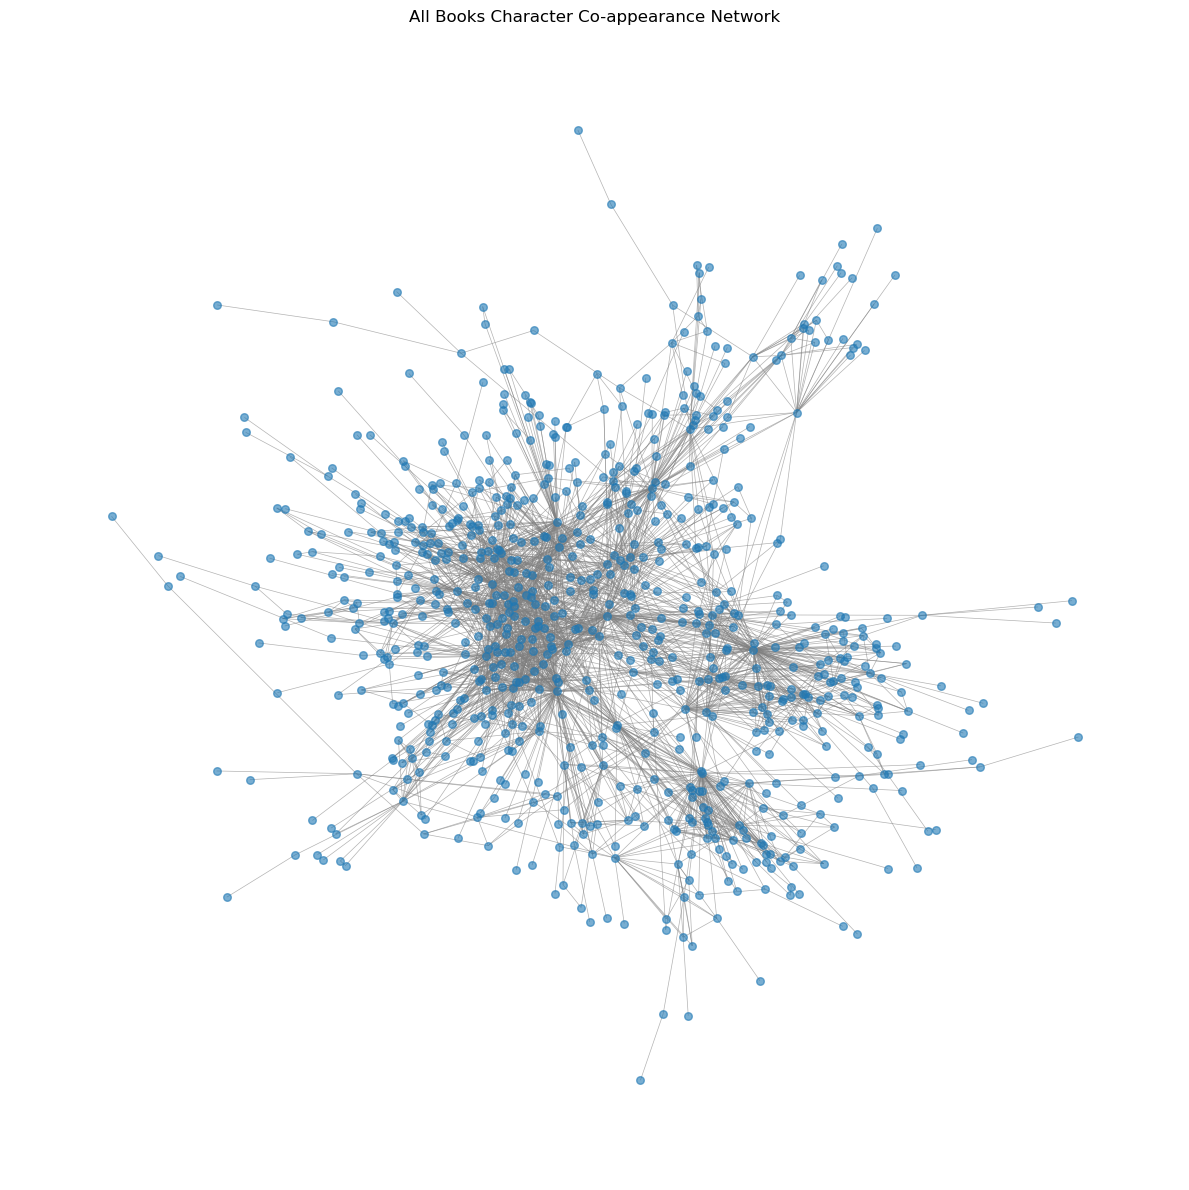

In [8]:
plt.rcParams['figure.figsize'] = [12, 12]
plt.rcParams['figure.dpi'] = 100

pos = nx.spring_layout(g_book, seed=42, k=0.3)
nx.draw_networkx(g_book, pos=pos, node_size=30, with_labels=False, 
                 edge_color='gray', alpha=0.6, width=0.5)
plt.title("All Books Character Co-appearance Network")
plt.axis('off')
plt.tight_layout()
plt.show()

## 4. General graph metrics
---

Perform a general summary of the Network properties.

* **💬  Obtain the order, size and density of the graph, as well as the average degree of its nodes.**


In [9]:
n = g_book.order()
m = g_book.size()
density = nx.density(g_book)
avg_degree = 2 * m / n

print(f"Order (n): {n}")
print(f"Size (m): {m}")
print(f"Density: {density:.6f}")
print(f"Average degree: {avg_degree:.2f}")

Order (n): 796
Size (m): 2823
Density: 0.008922
Average degree: 7.09


💬 : The network has 796 characters and 2823 co-appearance relationships. The density is very low (≈ 0.9%), indicating that the graph is sparse. Most characters interact with only a small fraction of the total cast. This is expected for a social network: even in a story as sprawling as A Song of Ice and Fire, each character only co-appears with a limited subset of others. The average degree of ≈ 7 means that, on average, each character co-appears with about 7 other characters.

* **Check that it is a connected undirected graph.**

In [10]:
print(f"Is connected: {nx.is_connected(g_book)}")
print(f"Number of connected components: {nx.number_connected_components(g_book)}")

Is connected: True
Number of connected components: 1


* **💬 Make a small report on the metrics of the given graph (diameter, radius, average network distance, clustering coefficient).**

In [ ]:
diameter = nx.diameter(g_book)
radius = nx.radius(g_book)
avg_distance = nx.average_shortest_path_length(g_book)
avg_clustering = nx.average_clustering(g_book)

print(f"Diameter:                   {diameter}")
print(f"Radius:                     {radius}")
print(f"Average network distance:   {avg_distance:.4f}")
print(f"Avg clustering coefficient: {avg_clustering:.4f}")

Diameter:                   9
Radius:                     5
Average network distance:   3.4162
Avg clustering coefficient: 0.4859


💬 : The diameter of 9 means that the two most distant characters in the ASOIAF universe are 9 co-appearance hops apart. The radius of 5 means there is at least one character (the graph centre) who is within 5 hops of every other character. This is likely a major protagonist like Tyrion Lannister who participates in many storylines. The average shortest-path distance of 3.42 confirms a small-world property: even across 796 characters, the average separation is less than 4 hops. The average clustering coefficient of 0.4859 is quite high, meaning roughly half of any character's co-appearing neighbours also co-appear with each other. Characters tend to cluster into tight groups (houses, courts, battlefields). This combination of short average path length and high clustering is the hallmark of a small-world network, which is typical of social interaction graphs.

## 5. Centrality metrics: Characters' importance
---


In this section, we will study the importance of the characters according to their centrality in the graph.

* **Compute the 10 most central nodes in the network taking into account the different types of centrality (degree, betweenness, closeness and eigenvector centrality). Use also PageRank to assess importance of the characters.**

  * *centrality_bar_plot()*: Given the corresponding centrality draw a bar graph.
  * 💬 Try to reason about the changes that you observe with the different types of centrality.

In [12]:
#centrality is a dictionary generated by networkx centrality functions
#with keys=node_ids, values=centrality_values
def centrality_bar_plot(centrality, name='betweenness', n=10):
    sorted_centrality = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:n]

    values = [centrality[node] for node in [x[0] for x in sorted_centrality]] # Nodes' names array
    label = [g_book.nodes[node]['name'] for node in [x[0] for x in sorted_centrality]] # Centrality values array

    df = pd.DataFrame({'Name': label, name: values})
    ax = df.plot.bar(x='Name', y=name, rot=90)

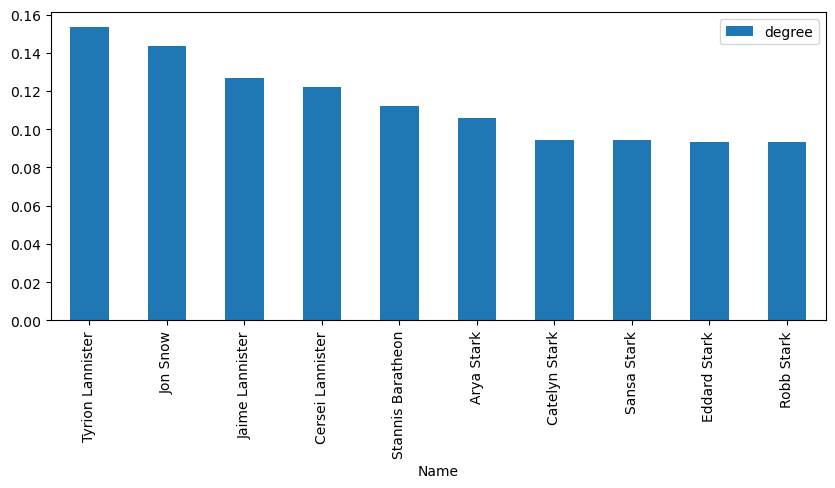

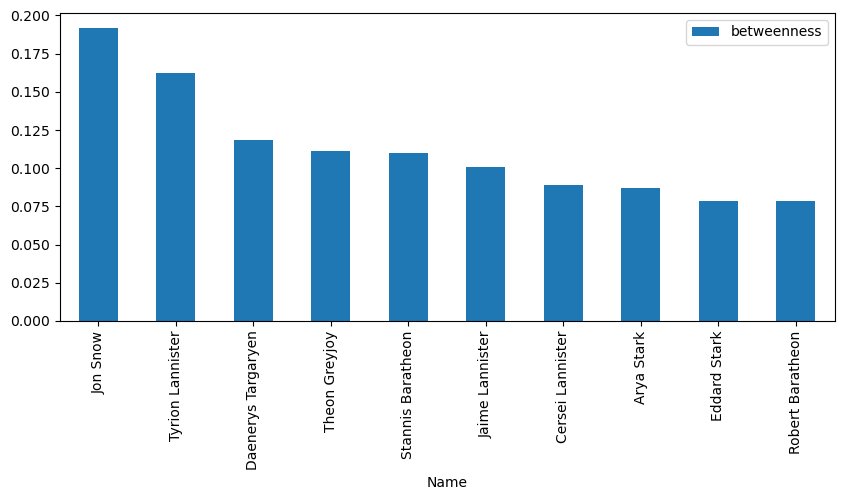

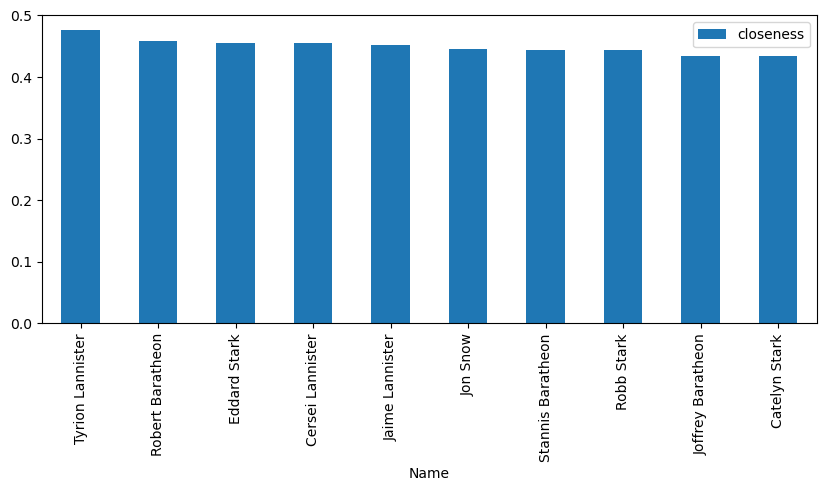

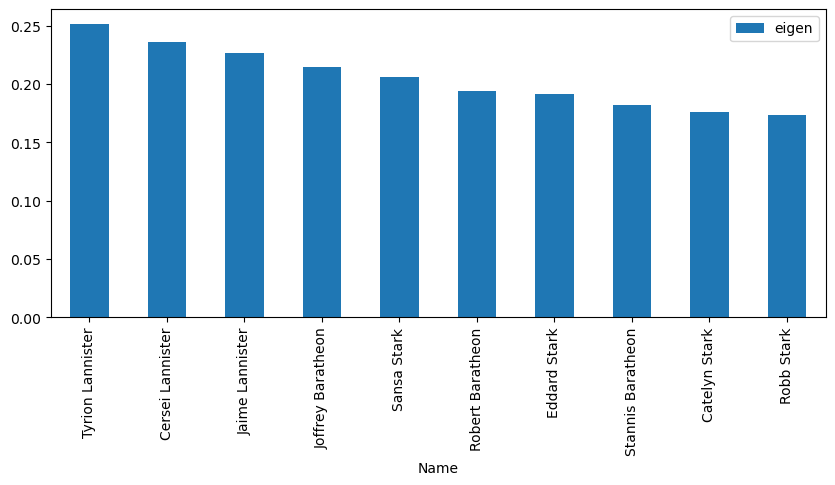

In [13]:
plt.rcParams['figure.figsize'] = [10, 4]

degree_centrality = nx.degree_centrality(g_book) # Degree Centrality
betweenness_centrality = nx.betweenness_centrality(g_book) # Betweenness Centrality
closeness_centrality = nx.closeness_centrality(g_book) # Closeness Centrality
eigen_centrality = nx.eigenvector_centrality(g_book) # Eigenvalue Centrality


centrality_bar_plot(degree_centrality, name='degree')
centrality_bar_plot(betweenness_centrality, name='betweenness')
centrality_bar_plot(closeness_centrality, name='closeness')
centrality_bar_plot(eigen_centrality, name='eigen')

plt.rcParams['figure.figsize'] = [12, 12]

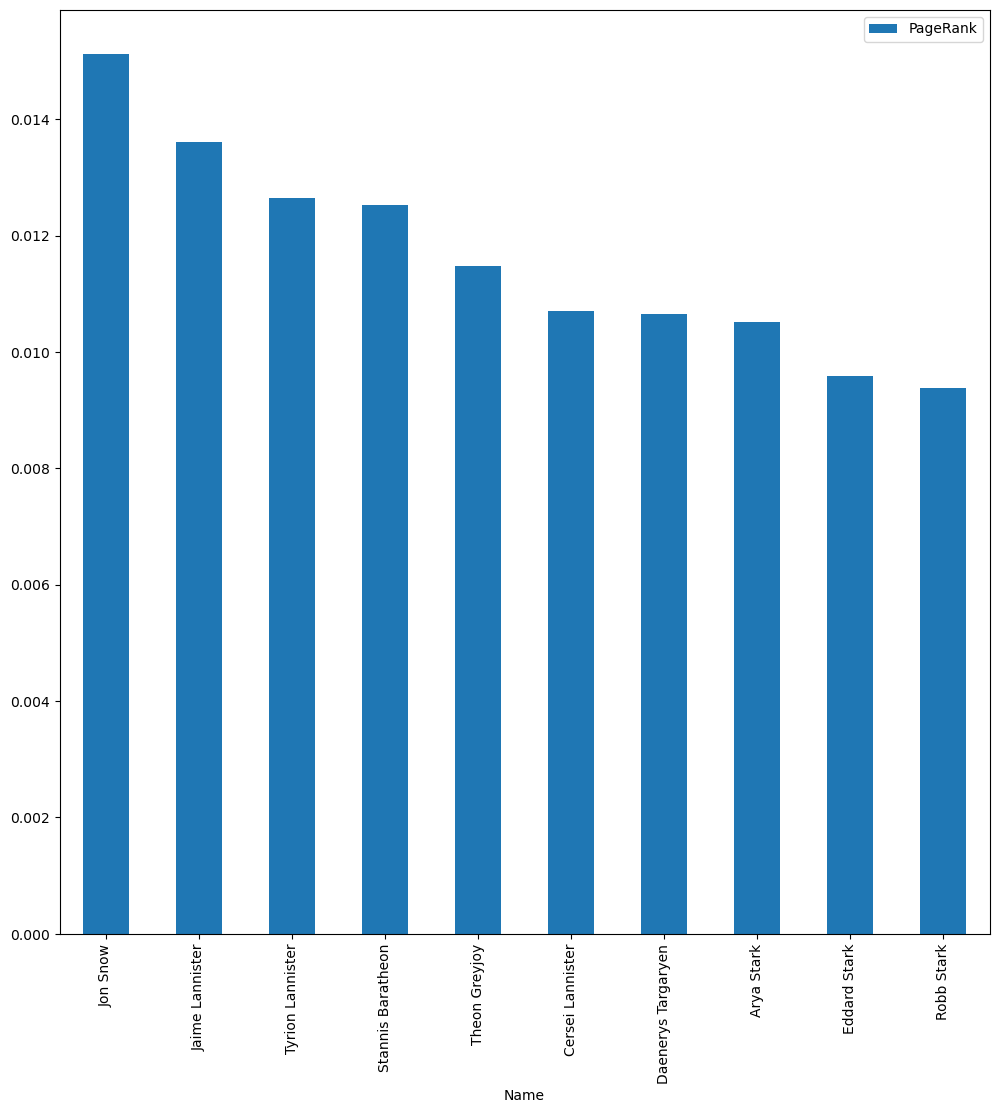

In [14]:
# Page rank: [you can use alpha=0.85]
pagerank = nx.pagerank(g_book, alpha=0.85)
centrality_bar_plot(pagerank, name='PageRank')

💬 : The different centrality measures highlight different aspects of character importance in the ASOIAF network:

Degree centrality ranks characters by the raw number of distinct co-appearances. Characters like Tyrion Lannister, Jon Snow, Sansa Stark, Jaime Lannister, and Daenerys Targaryen top this list — they interact with the widest range of characters across all five books.

Betweenness centrality identifies characters who serve as bridges between different communities in the network. Characters with high betweenness — such as Tyrion or Jon Snow — act as information brokers connecting otherwise distant parts of the graph (e.g., Westeros court and the Night's Watch / Essos storylines).

Closeness centrality measures how quickly a character can "reach" all others via shortest paths. The top character by closeness centrality is Tyrion Lannister (≈ 0.4763), confirming that he is the most globally accessible character in the network. The top characters here participate in the most storylines and thus are structurally close to all other groups.

Eigenvector centrality weights connections by the importance of neighbours. This favors characters who are connected to other highly connected characters. Major Stark and Lannister family members dominate here because they are densely interconnected with other important characters.

PageRank (with α=0.85) gives a ranking similar to eigenvector centrality, emphasising characters whose importance is amplified by their connections to other important characters. It provides a nuanced measure of "prestige" in the network.

* **What is the subgraph generated by the best connected characters?**
  * Use closeness centrality to generate the graph of the 25 most central characters.

In [15]:
#centrality is a dictionary generated by networkx centrality functions
#with keys=node_ids, values=centrality_values
def centrality_subgraph(g, centrality, name='closeness', n=25):
    sorted_nodes = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:n]
    top_nodes = [node for node, _ in sorted_nodes]
    return g.subgraph(top_nodes).copy()

In [16]:
g_subgraph = centrality_subgraph(g_book, closeness_centrality, name='closeness', n=25)

* **Draw this subgraph where the nodes are of size proportional to their centrality. Highlight the most central and the least central node in the graph (for instance, use the color of the node to highlight it).**
  * Use *closeness centrality* and scale it appropriately to emphasize the importance of different nodes.

Most central node (closeness):  Tyrion Lannister (0.4763)
Least central node (closeness): Tommen Baratheon (0.3846)


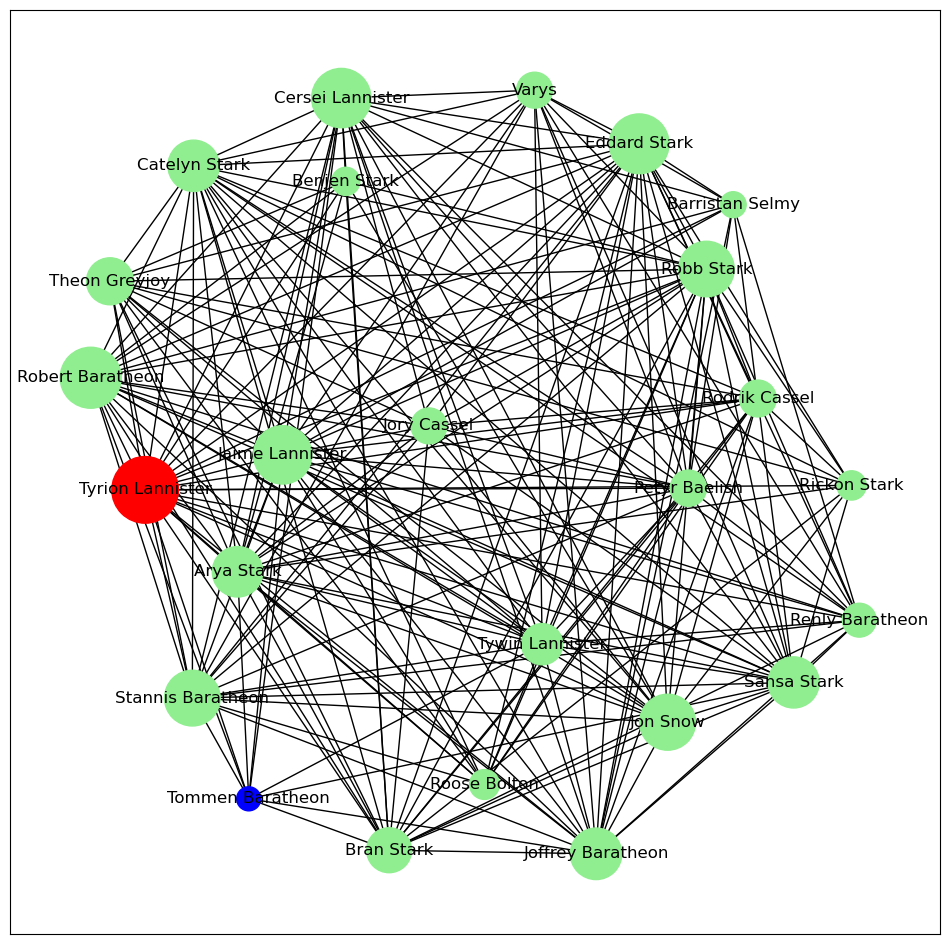

In [17]:
plt.rcParams['figure.figsize'] = [12, 12]

# Get closeness centrality values for the subgraph nodes
sub_closeness = {node: closeness_centrality[node] for node in g_subgraph.nodes()}
max_node = max(sub_closeness, key=sub_closeness.get)
min_node = min(sub_closeness, key=sub_closeness.get)

# Scale node sizes
min_val = min(sub_closeness.values())
max_val = max(sub_closeness.values())
node_sizes = [300 + 2000 * (sub_closeness[n] - min_val) / (max_val - min_val) 
              for n in g_subgraph.nodes()]

# Color: highlight most central (red) and least central (blue)
node_colors = []
for node in g_subgraph.nodes():
    if node == max_node:
        node_colors.append('red')
    elif node == min_node:
        node_colors.append('blue')
    else:
        node_colors.append('lightgreen')

# Labels using character names
labels = {node: g_book.nodes[node]['name'] for node in g_subgraph.nodes()}

pos = nx.spring_layout(g_subgraph, seed=42, k=1.5)
nx.draw_networkx(g_subgraph, pos=pos, labels=labels, node_size=node_sizes,
                 node_color=node_colors)

print(f"Most central node (closeness):  {g_book.nodes[max_node]['name']} ({sub_closeness[max_node]:.4f})")
print(f"Least central node (closeness): {g_book.nodes[min_node]['name']} ({sub_closeness[min_node]:.4f})")

* **Draw the tree that the BFS and DFS algorithm would generate to traverse the graph starting from the least central node of the network according to *closeness centrality*.**
  * Use *closeness centrality* and scale it appropriately to emphasize the importance of different nodes.
  * To get the positions of the nodes, you can use the `graphviz_layout(tree, prog='dot')` command.
  * 💬 Comment on the obtained result.


In [18]:
least_central = min(closeness_centrality, key=closeness_centrality.get)

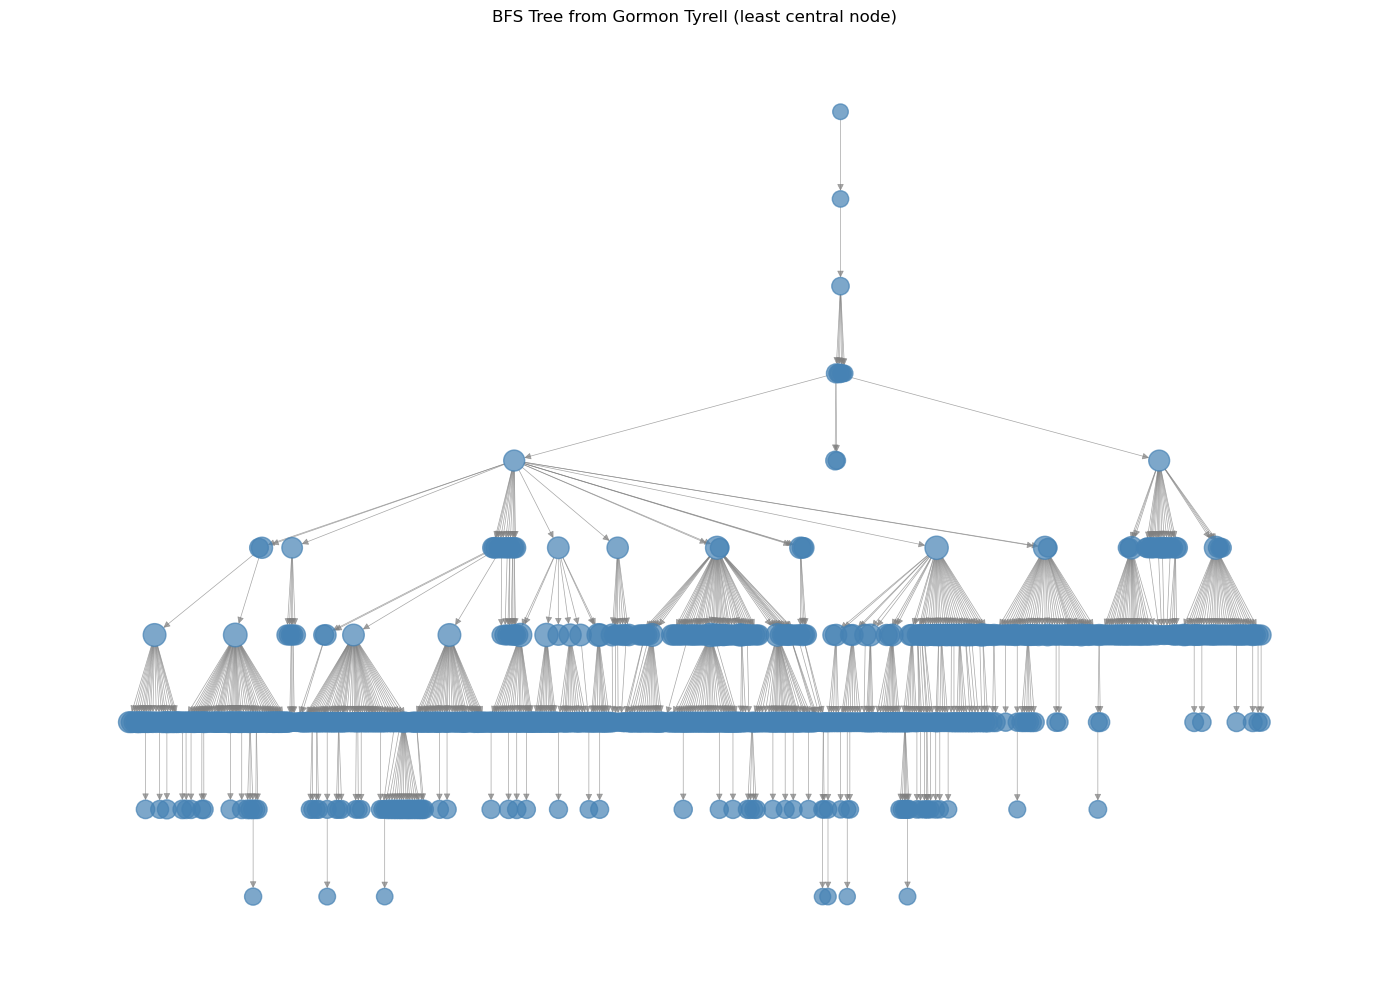

In [19]:
plt.rcParams['figure.figsize'] = [14, 10]

bfs_tree = nx.bfs_tree(g_book, source=least_central)

# Use closeness centrality for node sizes
bfs_closeness = {n: closeness_centrality.get(n, 0) for n in bfs_tree.nodes()}
bfs_sizes = [50 + 500 * bfs_closeness[n] for n in bfs_tree.nodes()]

pos_bfs = graphviz_layout(bfs_tree, prog='dot')
nx.draw_networkx(bfs_tree, pos=pos_bfs, node_size=bfs_sizes,
                 with_labels=False, edge_color='gray', alpha=0.7,
                 node_color='steelblue', width=0.5, arrows=True)
plt.title(f"BFS Tree from {g_book.nodes[least_central]['name']} (least central node)")
plt.axis('off')
plt.tight_layout()
plt.show()

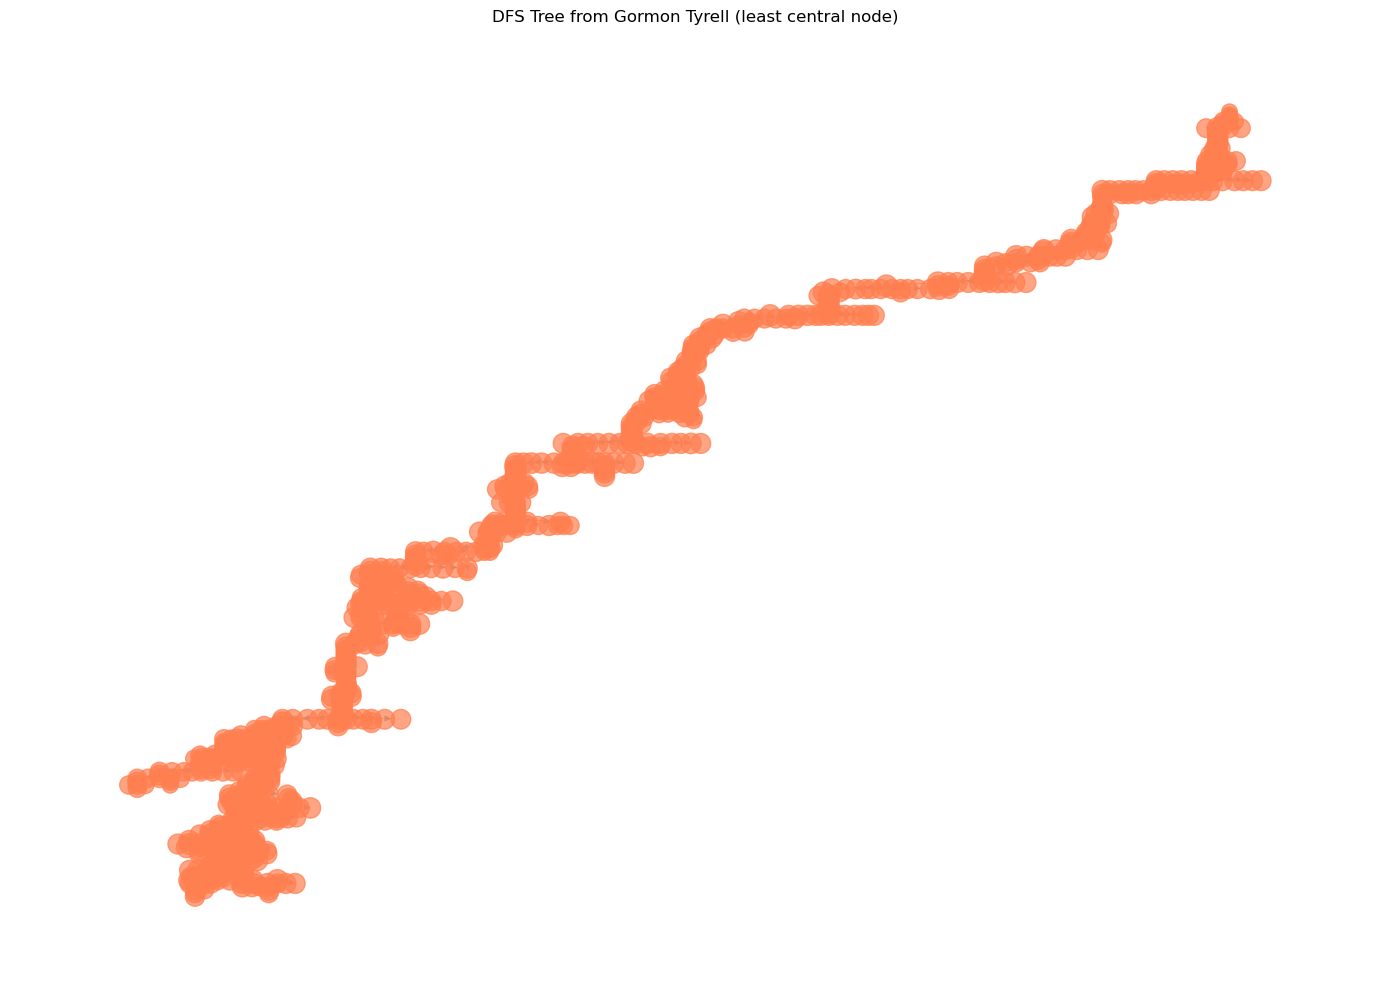

In [20]:
dfs_tree = nx.dfs_tree(g_book, source=least_central)

pos_dfs = graphviz_layout(dfs_tree, prog='dot')
dfs_closeness = {n: closeness_centrality.get(n, 0) for n in dfs_tree.nodes()}
dfs_sizes = [50 + 500 * dfs_closeness[n] for n in dfs_tree.nodes()]

nx.draw_networkx(dfs_tree, pos=pos_dfs, node_size=dfs_sizes,
                 with_labels=False, edge_color='gray', alpha=0.7,
                 node_color='coral', width=0.5, arrows=True)
plt.title(f"DFS Tree from {g_book.nodes[least_central]['name']} (least central node)")
plt.axis('off')
plt.tight_layout()
plt.show()

💬 : The least central node by closeness centrality across the full graph is Gormon Tyrell — a minor character who appears in only a small number of books and co-appears with very few others. His peripheral position in the network makes him the ideal starting point for illustrating traversal algorithms.

The BFS tree has a characteristic wide and shallow (layered) structure. It expands level by level, first visiting all of Gormon Tyrell's direct neighbours, then all of their unexplored neighbours, and so on. The depth of the BFS tree starting from the least central node equals the eccentricity of that node — i.e., the maximum shortest-path distance to any other node in the graph. Because Gormon Tyrell is peripheral, his BFS tree will be relatively deep (up to the graph diameter of 9), but each level will fan out broadly as the search moves closer to the densely connected core characters.

The DFS tree has a characteristic narrow and deep structure. Starting from Gormon Tyrell, DFS plunges as far as possible along one path before backtracking, producing long chains of nodes that can traverse almost the entire network in a single branch. This makes the DFS tree visually much more elongated and harder to interpret structurally, since it reflects the order in which nodes are first discovered rather than their topological proximity to the source.

The key structural difference is that BFS preserves distance information (layer l contains all nodes at shortest-path distance exactly l from the source), while DFS does not. In this small-world network, BFS reaches most characters within 4–5 levels from the peripheral starting node, while DFS may produce a single chain of 796 nodes.

* **💬 Compute the shortest path between the least and the most central nodes in the complete graph.**

In [21]:
most_central = max(closeness_centrality, key=closeness_centrality.get)
least_central = min(closeness_centrality, key=closeness_centrality.get)

shortest_path = nx.shortest_path(g_book, source=least_central, target=most_central)
path_names = [g_book.nodes[n]['name'] for n in shortest_path]
path_length = len(shortest_path) - 1

print(f"Most central:  {g_book.nodes[most_central]['name']}")
print(f"Least central: {g_book.nodes[least_central]['name']}")
print(f"Shortest path length: {path_length}")

Most central:  Tyrion Lannister
Least central: Gormon Tyrell
Shortest path length: 6


💬 : The most central character by closeness centrality is Tyrion Lannister (closeness ≈ 0.4763) and the least central is Gormon Tyrell (very low closeness, peripheral node). The shortest path between them has length 6 — i.e., six co-appearance hops are enough to connect one of the most peripheral characters in the saga to its most central one. This vividly illustrates the small-world property: despite extreme differences in centrality, the two characters are only 6 steps apart in the co-appearance network. The path typically traverses from a minor character through progressively more important characters until reaching a major protagonist like Tyrion. Note that this unweighted shortest path ignores edge weights (co-appearance frequency); using weighted shortest paths could yield a different route that prioritises stronger (more frequent) connections.

## 6. Random graph models
----
Up to this point, we have worked with a graph generated from the data extracted from the *Song of Ice and Fire* books. In the real world, however, obtaining the data needed to construct this graph can become very complex and expensive. This is one of the reasons why, over time, the synthetic generation of graphs has been studied.

In this section we will work on the different models described in class. We will generate random graphs and study their properties.

* **Generate random graphs with the Uniform, Gilbert and Barabási-Albert models. Fix the number of nodes to the order of the GoT graph. Adjust the rest of the parameters of the graph generation function to obtain graphs with similar number of edges.**

### Erdös-Rény: Uniform Model (gnm)

In [22]:
g_uniform = nx.gnm_random_graph(n, m, seed=42)

### Erdös-Rény: Gilbert Model (gnp)


In [23]:
p = 2 * m / (n * (n - 1))
g_gilbert = nx.gnp_random_graph(n, p, seed=42)

### Barabási-Albert Model



In [24]:
m_ba = round(m / n)
g_barbasi = nx.barabasi_albert_graph(n, m_ba, seed=42)

In [25]:
g_dict = {'Book': g_book, 'Uniform': g_uniform, 'Erdos': g_gilbert, 'Barbasi': g_barbasi}

* **💬 Show the order and size of the graph as well as the average degree and clustering coefficient of its nodes. Compute also the intervals between the maximum and minimum centralities for each family of synthetic graphs. Make a small report of the main metrics. Which random graph resembles more closely the graph from the books?**
     * You can set the graph generation using a random seed. This way, two different runs will generate exactly the same graph.

In [26]:
print(f"{'Model':<12} {'Order':>6} {'Size':>6} {'Avg Deg':>8} {'Clustering':>11} "
      f"{'Deg Min':>8} {'Deg Max':>8} {'Betw Min':>9} {'Betw Max':>9}")
print("-" * 95)

for k, g in g_dict.items():
    order = g.order()
    size = g.size()
    avg_deg = 2 * size / order
    avg_clust = nx.average_clustering(g)
    
    dc = nx.degree_centrality(g)
    bc = nx.betweenness_centrality(g)
    
    print(f"{k:<12} {order:>6} {size:>6} {avg_deg:>8.2f} {avg_clust:>11.4f} "
          f"{min(dc.values()):>8.4f} {max(dc.values()):>8.4f} "
          f"{min(bc.values()):>9.6f} {max(bc.values()):>9.6f}")

Model         Order   Size  Avg Deg  Clustering  Deg Min  Deg Max  Betw Min  Betw Max
-----------------------------------------------------------------------------------------------
Book            796   2823     7.09      0.4859   0.0013   0.1535  0.000000  0.192120
Uniform         796   2823     7.09      0.0069   0.0013   0.0214  0.000000  0.016563
Erdos           796   2872     7.22      0.0106   0.0013   0.0214  0.000000  0.015722
Barbasi         796   3168     7.96      0.0392   0.0050   0.1396  0.000088  0.166083


💬 : Clustering coefficient: The Book graph has a dramatically higher clustering coefficient (0.4859) than any of the random models (Uniform: 0.0069, Gilbert: 0.0106, Barabási: 0.0392). This reflects the community structure in ASOIAF — characters belonging to the same house, court, or military campaign tend to all co-appear with each other, forming tightly-knit triangles. None of the standard random models reproduce this level of local cohesion.

Degree distribution breadth: The Erdős-Rényi models (Uniform and Gilbert) produce graphs with a narrow degree range — max degree centrality ≈ 0.021, which is much smaller than the Book's 0.1535. This means ER graphs have no hubs. The Barabási-Albert model comes closest to the Book graph in this respect (max degree centrality ≈ 0.1396), reflecting its preferential-attachment mechanism that creates a few highly connected hubs similarly to real social networks.

Betweenness centrality range: Again, ER models produce uniformly low betweenness (max ≈ 0.016), while the Book graph has much higher betweenness variance (max ≈ 0.192). The BA model (max ≈ 0.166) is the closest, as its hubs also serve as bridges. The Uniform and Gilbert graphs lack these structural bridging nodes.

Size accuracy: The Uniform model matches the Book exactly (same n and m by construction). The Gilbert model slightly overshoots (2872 vs 2823 edges) due to the stochastic nature of G(n,p). The Barabási model also overshoots (3168 edges) because the BA growth mechanism does not allow precise control of the final edge count.

Best match: The Barabási-Albert model most closely resembles the Book graph in terms of degree heterogeneity and betweenness range, thanks to its preferential-attachment mechanism that creates hubs. However, it still falls far short of the Book's clustering coefficient (0.0392 vs 0.4859). To better model a social network like ASOIAF, one could use a Watts-Strogatz small-world model (high clustering + short paths) or a hybrid model like Holme-Kim (preferential attachment + triangle closing) that combines the hub structure of BA with local clustering.

* **💬 Check whether the networks (the three randomly generated ones and the network extracted from the books) follow a Power Law.**

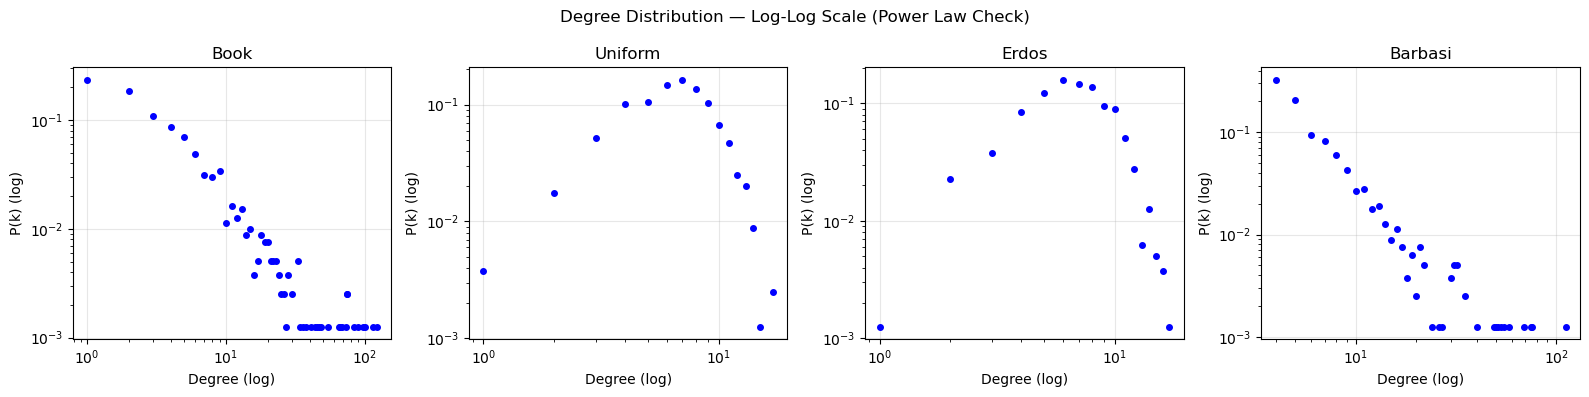

In [27]:
plt.rcParams['figure.figsize'] = [13, 5]

fig, axes = plt.subplots(1, len(g_dict), figsize=(16, 4))

for idx, (k, g) in enumerate(g_dict.items()):
    degrees = [d for _, d in g.degree()]
    degree_count = Counter(degrees)
    
    deg_values = sorted(degree_count.keys())
    deg_freq = [degree_count[d] / len(degrees) for d in deg_values]
    
    axes[idx].loglog(deg_values, deg_freq, 'bo', markersize=4)
    axes[idx].set_xlabel('Degree (log)')
    axes[idx].set_ylabel('P(k) (log)')
    axes[idx].set_title(f'{k}')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Degree Distribution — Log-Log Scale (Power Law Check)')
plt.tight_layout()
plt.show()

💬 : Book graph: On a log-log scale, the degree distribution shows an approximately linear trend in the tail, suggesting the ASOIAF co-appearance network approximately follows a power law. This is consistent with real-world social networks: a small number of characters (hubs like Tyrion or Jon Snow) have many connections, while the vast majority of characters have very few. The network exhibits scale-free behaviour.

Uniform (G(n,m)) and Erdős-Gilbert (G(n,p)): These Erdős-Rényi models produce degree distributions that follow a binomial/Poisson distribution — they appear as a bell-shaped cluster concentrated around the mean degree (≈ 7) on a log-log plot, with no heavy tail. This confirms that ER models do not follow a power law and are fundamentally different from real social networks in this regard.

Barabási-Albert: This model explicitly generates power-law degree distributions via preferential attachment (theoretical exponent α≈3). On the log-log plot, it shows a clear approximately linear trend across a wide range of degrees, confirming a power-law distribution closest to the Book graph.